## University of Surrey
### MSc Data Science Dissertation - Emotion Aware Music Recommendation System with Explainable AI
###Model training and Benchmark evaluation

Name: Minal Honali Raghunandan


Student ID: 6908107


Notebook2 -
implementing multi target regression to predict continuous valence and arousal emotion coordinates from acoustic feautures extracted via openSMILE

In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/Dissertation/data/processed"
X_train = pd.read_csv(os.path.join(DATA_PATH, "X_train.csv"))
y_train = pd.read_csv(os.path.join(DATA_PATH, "y_train.csv"))
X_test = pd.read_csv(os.path.join(DATA_PATH, "X_test.csv"))
y_test = pd.read_csv(os.path.join(DATA_PATH, "y_test.csv"))

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(1395, 302) (1395, 2) (349, 302) (349, 2)


In [13]:
# Sanitize feature column names for XGBoost
regex_pattern = re.compile(r"\[|\]|<", re.IGNORECASE)

X_train.columns = [
    regex_pattern.sub("_", col) if isinstance(col, str) else col
    for col in X_train.columns
]
X_test.columns = [
    regex_pattern.sub("_", col) if isinstance(col, str) else col
    for col in X_test.columns
]

In [14]:

from sklearn.model_selection import KFold, cross_validate

kf = KFold(n_splits=5, shuffle=True, random_state=42)

score = {
    'r2': 'r2',
    'neg_rmse': 'neg_root_mean_squared_error',
    'neg_mae': 'neg_mean_absolute_error'
}

def cross_val(model, x, y, target_name, model_name):
  scores = cross_validate(model, x, y, cv=kf, scoring=score, return_train_score=False)
  return {
      'Model': model_name,
      'Target': target_name,
      'R2': round(np.mean(scores['test_r2']),4),
      'RMSE': round(-np.mean(scores['test_neg_rmse']),4),
      'MAE': round(-np.mean(scores['test_neg_mae']),4)
  }

In [15]:
models = {
    'Ridge Regression': Ridge(alpha=10.0, random_state=42),
    'XGBoost Regression': xgb.XGBRegressor(n_estimators=100, max_depth=4,learning_rate=0.1, random_state=42),
    'MLP Regression': MLPRegressor(hidden_layer_sizes=(128,64), max_iter=500, random_state=42, early_stopping=True)
}

targets = {'Valence': 0, 'Arousal': 1}

cv_res = []

for model_name, model in models.items():
  for target_name, target_idx in targets.items():
    result = cross_val(model, X_train, y_train.iloc[:, target_idx], target_name, model_name)
    cv_res.append(result)

df_cv_res = pd.DataFrame(cv_res)
print("\n===CROSS VALIDATION RESULTS===")
print(df_cv_res.pivot(index='Model', columns='Target'))



===CROSS VALIDATION RESULTS===
                        R2            RMSE             MAE        
Target             Arousal Valence Arousal Valence Arousal Valence
Model                                                             
MLP Regression      0.0501 -0.1603  0.3138  0.3158  0.2407  0.2472
Ridge Regression    0.5041  0.4263  0.2261  0.2223  0.1775  0.1742
XGBoost Regression  0.5688  0.5115  0.2110  0.2053  0.1644  0.1623


Using 5-fold cross-validation on the training set, XGBoost emerged as the best-performing
model, with a mean R² of 0.5688 for arousal and 0.5115 for valence (vs. 0.5041/0.4263 for
Ridge, and near-zero/negative for MLP). This is a more conservative and reliable estimate
than a single train/test split would give, since it averages performance across 5
independent folds rather than relying on one potentially favourable split.

Consistent with prior work in Music Emotion Recognition (MER), arousal is consistently
easier to predict from acoustic features than valence across all three models tested.
This aligns with the literature: dynamics, energy, and timbre features openSMILE
captures directly correlate strongly with arousal, whereas valence is more dependent
on harmony, lyrical content, and subjective/cultural interpretation, which low-level
acoustic descriptors capture less directly.

MLP Regression performed poorly across both targets (R² = 0.0501 arousal, -0.1603
valence), even with early stopping enabled. A negative R² indicates the model performed
worse than simply predicting the mean valence for every sample. This is likely due to
the relatively small training set (1,395 samples) relative to the model's parameter
count (128→64 hidden units), making MLP prone to underfitting or unstable convergence
without more extensive regularisation or a larger dataset - a known limitation of neural
approaches on tabular data of this scale.

Given these results, XGBoost was selected for hyperparameter tuning and final model
training (see below).

In [18]:
#tuning
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100,200,300,400],
    'max_depth': [3,4,5,6],
    'learning_rate': [0.01,0.1,0.2,0.3],
    'subsample': [0.8,0.9,1.0],
    'colsample_bytree': [0.8,0.9,1.0],
}

best_models = {}

for target_name, target_id in targets.items():
  search = RandomizedSearchCV(
      xgb.XGBRegressor(random_state=42),
      param_distributions=param_grid,
      n_iter=15,
      cv=kf,
      scoring='r2',
      n_jobs=-1,
      verbose=1
  )
  search.fit(X_train, y_train.iloc[:, target_id])
  best_models[target_name] = search.best_estimator_
  print(f"Best parameters for {target_name}:")
  print(search.best_params_)


Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters for Valence:
{'subsample': 1.0, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters for Arousal:
{'subsample': 1.0, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.9}


best parameters for arousal and valence are shown in the above output. Arousal needs a shallower depth of 3 depicting exactly that arousal is driven by few strong energy features needing few tree depth. Valence depends more on subtle interacting timbral cues, hence it requires more tree depth

both have different optimal hyperparameters hence it is best to have two separate models for better performance

In [19]:
final_res = []
for target_name, target_id in targets.items():
  model = best_models[target_name]
  y_pred = model.predict(X_test)
  y_true = y_test.iloc[:, target_id]

  r2 = r2_score(y_true, y_pred)
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))
  mae = mean_absolute_error(y_true, y_pred)

  final_res.append({
      'Target': target_name,
      'R2': round(r2,4),
      'RMSE': round(rmse,4),
      'MAE': round(mae,4)
  })

print(f"{target_name} — Test R²: {round(r2,4)} | RMSE: {round(rmse,4)} | MAE: {round(mae,4)}")

df_final = pd.DataFrame(final_res)
print("\n===FINAL RESULTS===")
print(df_final)



Arousal — Test R²: 0.6375 | RMSE: 0.1913 | MAE: 0.1495

===FINAL RESULTS===
    Target      R2    RMSE     MAE
0  Valence  0.5208  0.1988  0.1615
1  Arousal  0.6375  0.1913  0.1495


In [20]:
import joblib

MODEL_DIR = "/content/drive/MyDrive/Dissertation/models"
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(best_models['Valence'], os.path.join(MODEL_DIR, "valence_model.pkl"))
joblib.dump(best_models['Arousal'], os.path.join(MODEL_DIR, "arousal_model.pkl"))
joblib.dump(list(X_train.columns), os.path.join(MODEL_DIR, "feature_columns.pkl"))

print(f"Models saved to {MODEL_DIR}")

Models saved to /content/drive/MyDrive/Dissertation/models


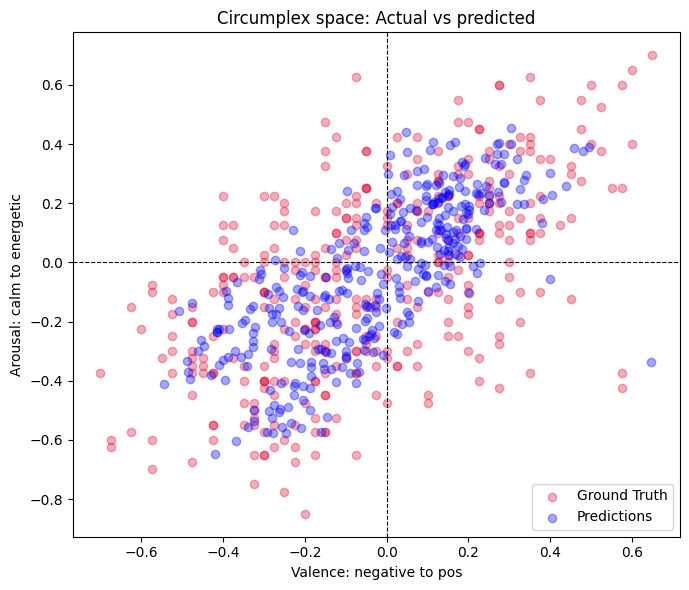

In [21]:
y_pred_valence = best_models['Valence'].predict(X_test)
y_pred_arousal = best_models['Arousal'].predict(X_test)
y_pred_xg = np.column_stack((y_pred_valence, y_pred_arousal))
plt.figure(figsize=(7,6))

# 2D CIRCUMPLEX EMOTION SPACE (GROUND TRUTH VS PREDICTIONS)
plt.scatter(y_test.iloc[:,0],y_test.iloc[:,1], alpha = 0.35, color = "crimson", label = "Ground Truth")
plt.scatter(y_pred_xg[:,0], y_pred_xg[:,1], alpha = 0.35, color = "blue", label = "Predictions")
plt.axhline(0,color="black", linestyle="--",linewidth=0.8)
plt.axvline(0,color="black", linestyle="--",linewidth=0.8)
plt.xlabel("Valence: negative to pos")
plt.ylabel("Arousal: calm to energetic")
plt.title("Circumplex space: Actual vs predicted")
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

The scatter plot evaluates the model's predictions against ground truth ratings across the 2D **Valence-Arousal Circumplex Model of Affect**:

**Circumplex Quadrant Mapping:**
  * Top-Right Quadrant (+V, +A): High-energy, positive emotions (Happy, Excited, Triumphant).
  * Bottom-Left Quadrant (-V, -A): Low-energy, negative emotions (Sad, Somber, Melancholic).
  * Top-Left Quadrant (-V, +A): High-energy, negative emotions (Angry, Frantic, Tense).
  * Bottom-Right Quadrant (+V, -A): Low-energy, positive emotions (Calm, Peaceful, Serene).

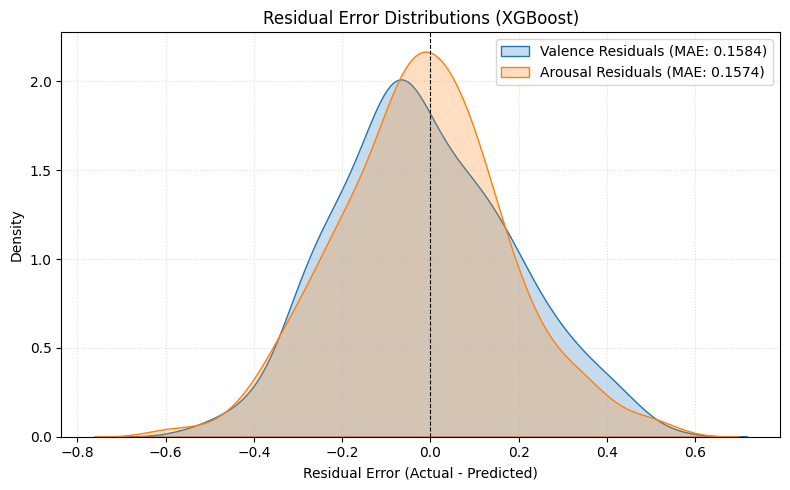

In [22]:
res_valence = y_test.iloc[:, 0] - y_pred_xg[:, 0]
res_arousal = y_test.iloc[:, 1] - y_pred_xg[:, 1]

plt.figure(figsize=(8, 5))

sns.kdeplot(res_valence, label="Valence Residuals (MAE: 0.1584)", fill=True)
sns.kdeplot(res_arousal, label="Arousal Residuals (MAE: 0.1574)", fill=True)

plt.axvline(0, color="black", linestyle="--", linewidth=0.8)
plt.xlabel("Residual Error (Actual - Predicted)")
plt.ylabel("Density")
plt.title("Residual Error Distributions (XGBoost)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.4)

plt.tight_layout()
plt.show()

* **Performance:** Valence $\text{MAE} = 0.1584$, Arousal $\text{MAE} = 0.1574$.
* **Distribution:** Both residuals show near-Gaussian distributions centered around zero, indicating stable predictions with low variance.
* **Bias:** Arousal is unbiased (mode $\approx 0.0$); Valence exhibits a minor overprediction bias (mode $\approx -0.07$).
* **Tails:** Rapid tapering past $\pm 0.5$ confirms minimal extreme outlier errors.

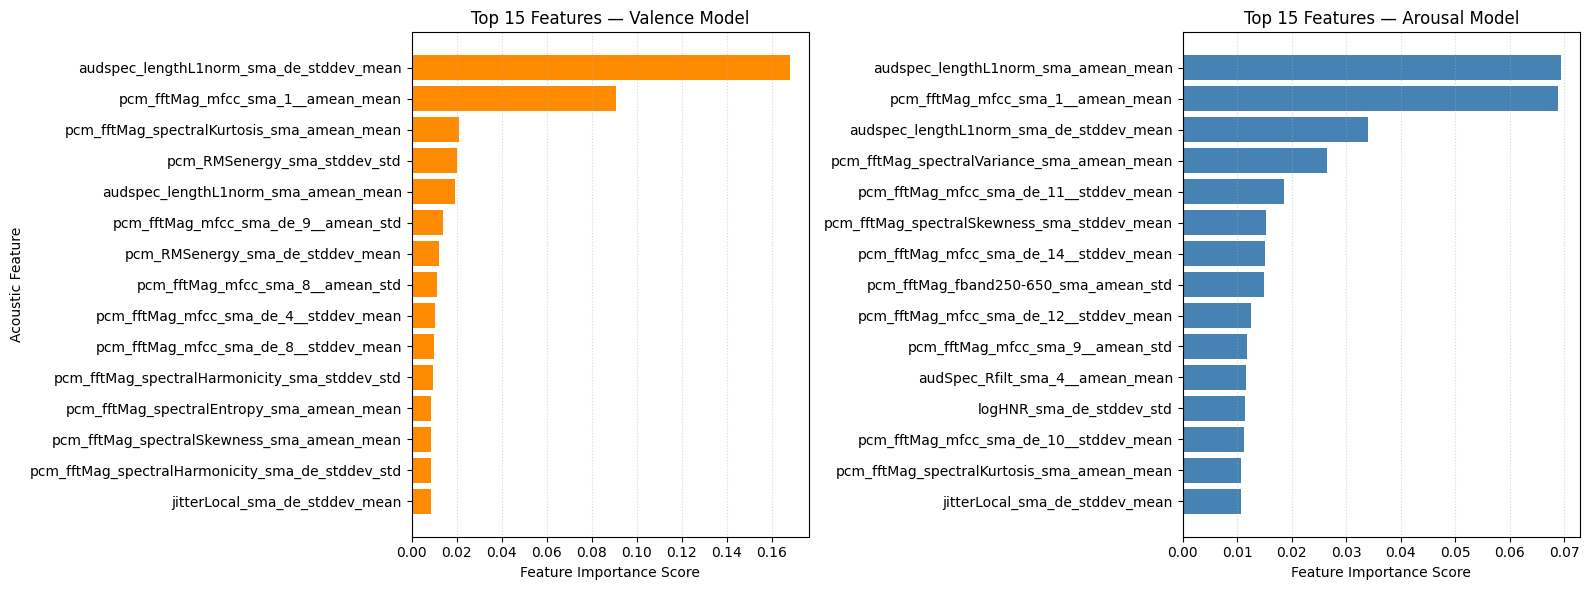

In [23]:
importances_valence = best_models['Valence'].feature_importances_
importances_arousal = best_models['Arousal'].feature_importances_

top_v = np.argsort(importances_valence)[-15:]
top_a = np.argsort(importances_arousal)[-15:]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(np.array(X_train.columns)[top_v], importances_valence[top_v], color="darkorange")
axes[0].set_xlabel("Feature Importance Score")
axes[0].set_ylabel("Acoustic Feature")
axes[0].set_title("Top 15 Features — Valence Model")
axes[0].grid(axis="x", linestyle=":", alpha=0.5)

axes[1].barh(np.array(X_train.columns)[top_a], importances_arousal[top_a], color="steelblue")
axes[1].set_xlabel("Feature Importance Score")
axes[1].set_title("Top 15 Features — Arousal Model")
axes[1].grid(axis="x", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

Feature Importance Analysis

* **Key Drivers**: I observed that loudness and energy dynamics (audspec_lengthL1norm, spectral variance) drive my model's **Arousal** predictions, while timbral features (mfcc_1, higher-order MFCC deltas) primarily separate bright from dark textures for **Valence**.
* **Micro-Dynamics**: I found that features capturing acoustic roughness and pitch stability (spectralHarmonicity, jitterLocal, shimmerLocal, logHNR) provide consistent secondary signals.
* **Feature Weights**: The top three energy and timbral features provide the highest individual gains (> 0.03), while the remaining acoustic descriptors contribute a balanced, distributed influence across the model.

## NOTEBOOK SUMMARY

- Data loading

- Model comparison- Ridge regression, XGBoost, MLP (5 fold CV)

 - hyperparameter tuning - RandomizedSearchCV

 - final model fitting and test set evaluation

 - visualisation